## Time series clustering

Clustering is an unsupervised learning task that partitions a set of unlabeled data objects into homogeneous groups or clusters. Since we are in the unsupervised environment, we do not have advanced knowledge of the definitions or classifications of the groups. The goal of such a task is to form clusters in which individuals have maximum similarity to other individuals within the group and minimum similarity to individuals in other groups. This approach can be used for data mining, identifying structures in unlabeled datasets, data summarization, or as a preprocessing step in a more complex modeling system.

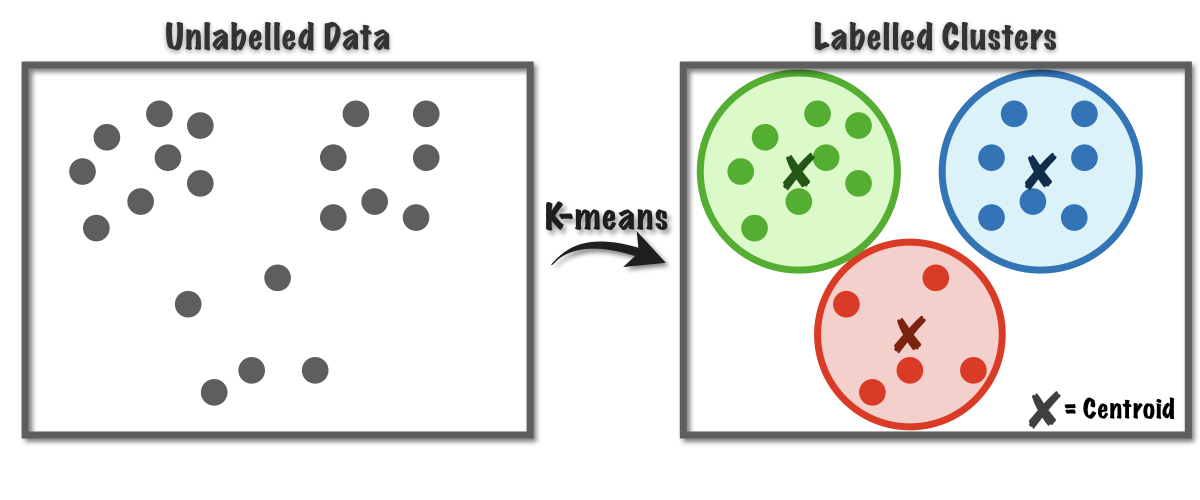

## Time series clustering

Data for many applications are stored in time series format, for example: weather data, sales data, biomedical measurements like blood pressure and electrocardiogram, stock prices, biometric data, etc. Consequently, different works are found in a variety of domains, such as energy, finance, bioinformatics, or biology. Many relevant projects for analyzing time series have been carried out in various areas for different purposes, such as: subsequence matching, anomaly detection, motif discovery, indexing, visualization, segmentation, pattern identification, trend analysis, summarization, and forecasting.

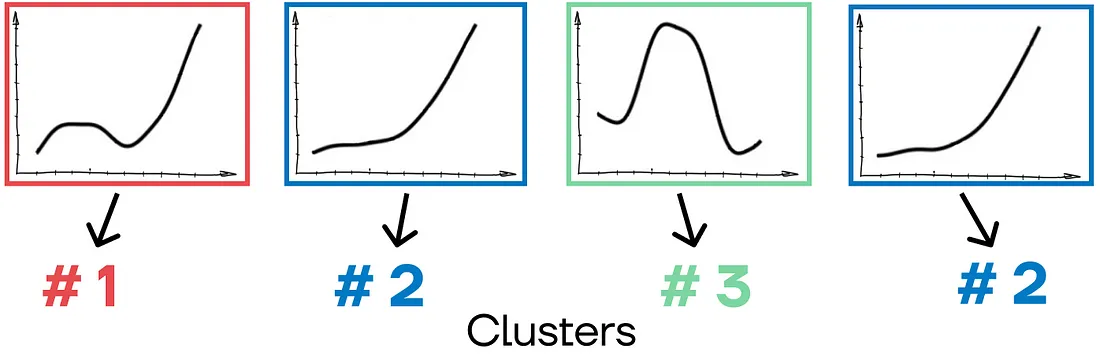

## What are the main challenges?

Clustering time series in the context of large datasets is a difficult problem for two main reasons. First, time series data is often high-dimensional, which makes handling such data slow and difficult for many clustering algorithms. The second challenge concerns the similarity measures used to perform the clustering.


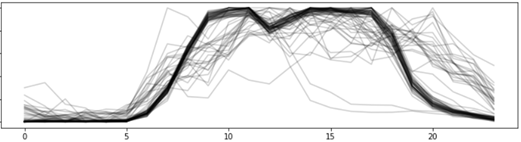

## Methods for clustering time series

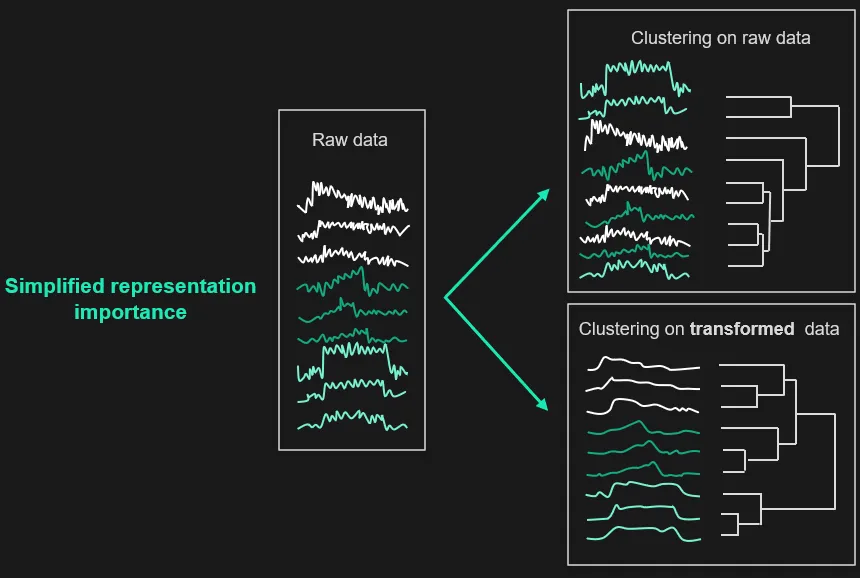

### **From raw series (grouping based on temporal proximity)**

Classical clustering methods can be applied directly to the initial series.

But be careful, in this case the choice of distance/similarity measure must be carefully considered before applying the algorithm. The selection involves determining what is meant by “similarity” between individual time series and can vary depending on the particularities of the data.

In practice, we rarely use the raw series directly. Instead, preliminary processing is performed to produce a simplified version of the series.

### **From a simplified representation of the series (representation-based grouping)**

Simplified representation with rapid reduction of problem dimension

Raw data can be processed before clustering by applying transformations: standardization, smoothing, interpolation, stationarization, etc. These processes can remove noise and unwanted trends from the data and we can apply clustering algorithms to the resulting series.

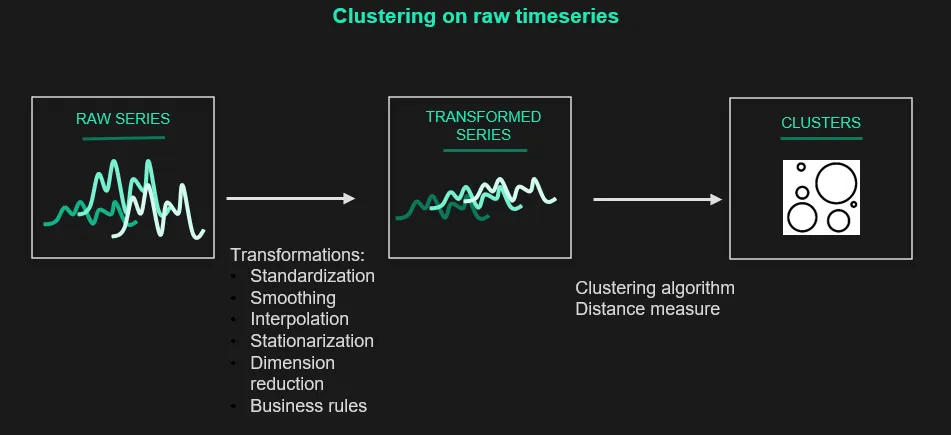

## Distance measuermentes
Hundreds of distances have been proposed to classify data, of which Euclidean distance is the most popular. However, when it comes to clustering time series, using Euclidean distance, or any other Minkowski metric, on raw data can lead to counterintuitive results. In particular, this distance is very sensitive to scale effects and outliers or missing data points. Euclidean distance does not allow for temporal shifts to be taken into account. In fact, very similar signals can be shifted in time and would not be measured as “close” by the standard Euclidean distance. To solve this problem, there are adapted metrics, such as the DTW (Dynamic Time Warping) distance.

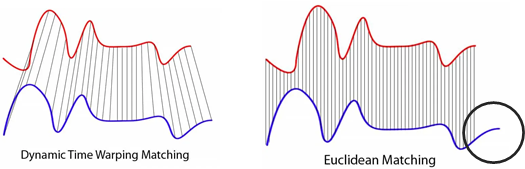

This distance takes into account non-linear elastic time and, consequently, accounts for relative temporal changes of two series by deforming the time axis. Intuitively, this means that this distance does not only compare points with corresponding timestamps. Thus, the Euclidean distance takes into account only simultaneous events, while the DTW distance takes into account out-of-phase events. Of course, it is not a magic measure that works in all cases. There is no single metric or clustering algorithm that can be considered superior to all others. It all depends on the context of the application, so it is up to you to experiment with different alternatives and choose the best one.

Depending on the measure selected, the resulting clusters may be "closer" in time or shape. These differences in clustering parameters can also be impacted by the data processing methods discussed above. Depending on the clustering objective and the length of the time series, the four data processing methods mentioned above can be tested. Clustering can be applied to the raw time series, to a simplified representation of the series, to time series models, or to extracted features. Measures can then be applied impacting the temporal or geometric similarity of the clusters.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap
import geopandas as gpd

In [3]:

ee.Authenticate()
ee.Initialize(project = 'analog-foundry-466522-c7')

In [4]:
path_agua = '/content/drive/MyDrive/AlvaroSampaio/GeoScan/Pontos_LST/Pontos_agua.shp'
path_cana = '/content/drive/MyDrive/AlvaroSampaio/GeoScan/Pontos_LST/Pontos_cana.shp'
path_cidade = '/content/drive/MyDrive/AlvaroSampaio/GeoScan/Pontos_LST/Pontos_cidade.shp'
path_reserva = '/content/drive/MyDrive/AlvaroSampaio/GeoScan/Pontos_LST/Pontos_reserva.shp'

In [5]:
gdp_agua = gpd.read_file(path_agua)
gdp_cana = gpd.read_file(path_cana)
gdp_cidade = gpd.read_file(path_cidade)
gdp_reserva = gpd.read_file(path_reserva)

In [6]:
gdp_agua['id'] = 1
gdp_cana['id'] = 2
gdp_cidade['id'] = 3
gdp_reserva['id'] = 4

In [7]:
gdp_agua.head()

,id,geometry
0,1,POINT (-50.65727 -20.92599)
1,1,POINT (-50.61445 -20.94601)
2,1,POINT (-50.58219 -20.96881)
3,1,POINT (-50.55605 -20.98939)
4,1,POINT (-50.54549 -21.00385)


In [8]:
#Juntando todos os pontos em um dataframe
gdp_full = pd.concat([gdp_agua, gdp_cana, gdp_cidade, gdp_reserva])

In [9]:
#Convertendo a feature collection em um geemap
fc= geemap.geopandas_to_ee(gdp_full)

In [10]:
Map = geemap.Map()
Map.centerObject(fc, 10)
Map.addLayer(fc, {}, "Points")
Map

Map(center=[-21.178861570498505, -50.50426158562062], controls=(WidgetControl(options=['position', 'transparen…

In [11]:
months = ee.List.sequence(1,12)
years = ee.List.sequence(2019, 2021)

In [12]:
landsat_collection = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterDate('2019-01-01', '2021-12-31').filterBounds(fc)

In [13]:
def calculate_ndvi(image):
  #calculando ndvi
  ndvi = image.normalizedDifference(['SR_B5', 'SR_B4']).rename('NDVI')
  return image.addBands(ndvi)
landsat_ndvi = landsat_collection.map(calculate_ndvi)

In [14]:
def monthly(collection):
  img_coll = ee.ImageCollection([])
  for y in years.getInfo():
    for m in months.getInfo():
      filtered = collection.filter(ee.Filter.calendarRange(y, y, 'year')).filter(ee.Filter.calendarRange(m, m, 'month'))
      filtered = filtered.median()
      img_coll = img_coll.merge(filtered.set('year', y).set('month', m).set('system:time_start', ee.Date.fromYMD(y, m, 1).getInfo()['value']))
  return img_coll

In [15]:
#Vamos palicar ossa fnção ára pbter o vlaores mensais do NDVI do landsat
Monthly_MD = monthly(landsat_ndvi)

In [16]:
image_list = Monthly_MD.toList(Monthly_MD.size())
for i in range(image_list.size().getInfo()):
  image = ee.Image(image_list.get(i))
  band_names = image.bandNames().getInfo()
  print(f"Image {i+1}: {band_names}")


Image 1: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDVI']
Image 2: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDVI']
Image 3: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDVI']
Image 4: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_CDIST', 'ST_DRAD', 'ST_EMIS', 'ST_EMSD', 'ST_QA', 'ST_TRAD', 'ST_URAD', 'QA_PIXEL', 'QA_RADSAT', 'NDVI']
Image 5: ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'SR_QA_AEROSOL', 'ST_B10', 'ST_ATRAN', 'ST_

In [17]:
def print_image_dates(image_collection):
  image_list = image_collection.toList(image_collection.size())
  for i in range(image_collection.size().getInfo()):
    image = ee.Image(image_list.get(i))
    date_ms = image.get('system:time_start').getInfo()
    date = ee.Date(date_ms).format('YYYY-MM-dd').getInfo()
    print(f"Image {i+1}: {date}")


print_image_dates(Monthly_MD)


Image 1: 2019-01-01
Image 2: 2019-02-01
Image 3: 2019-03-01
Image 4: 2019-04-01
Image 5: 2019-05-01
Image 6: 2019-06-01
Image 7: 2019-07-01
Image 8: 2019-08-01
Image 9: 2019-09-01
Image 10: 2019-10-01
Image 11: 2019-11-01
Image 12: 2019-12-01
Image 13: 2020-01-01
Image 14: 2020-02-01
Image 15: 2020-03-01
Image 16: 2020-04-01
Image 17: 2020-05-01
Image 18: 2020-06-01
Image 19: 2020-07-01
Image 20: 2020-08-01
Image 21: 2020-09-01
Image 22: 2020-10-01
Image 23: 2020-11-01
Image 24: 2020-12-01
Image 25: 2021-01-01
Image 26: 2021-02-01
Image 27: 2021-03-01
Image 28: 2021-04-01
Image 29: 2021-05-01
Image 30: 2021-06-01
Image 31: 2021-07-01
Image 32: 2021-08-01
Image 33: 2021-09-01
Image 34: 2021-10-01
Image 35: 2021-11-01
Image 36: 2021-12-01


In [18]:
feature_list = fc.toList(fc.size())
dfs = []

for i in range(fc.size().getInfo()):
  feature = ee.Feature(feature_list.get(i))
  class_id = feature.get('id').getInfo()
  time_series = Monthly_MD.select('NDVI').getRegion(feature.geometry(), 30).getInfo()
  df = pd.DataFrame(time_series[1:], columns=time_series[0])
  df = df[['longitude', 'latitude', 'time', 'NDVI']]
  df.rename(columns={'time':'date'}, inplace=True)

  # Convert the date from milliseconds to datetime objects.
  df['date'] = pd.to_datetime(df['date'], unit='ms')
  df = df.set_index('date')
  df['feature_id'] = i
  df['class_id'] = class_id
  dfs.append(df)

final_df = pd.concat(dfs)
final_df

,longitude,latitude,NDVI,feature_id,class_id
date,,,,,
2019-01-01,-50.657301,-20.926120,0.094833,0,1
2019-02-01,-50.657301,-20.926120,0.116266,0,1
2019-03-01,-50.657301,-20.926120,0.041275,0,1
2019-04-01,-50.657301,-20.926120,-0.003463,0,1
2019-05-01,-50.657301,-20.926120,0.042498,0,1
...,...,...,...,...,...
2021-08-01,-50.521746,-21.084044,0.169276,105,4
2021-09-01,-50.521746,-21.084044,0.296380,105,4
2021-10-01,-50.521746,-21.084044,0.311862,105,4


In [19]:
final_df.drop(columns={'longitude','latitude'}, inplace=True)

In [20]:
final_df['date'] = final_df.index

In [21]:
import plotly.express as px


fig = px.line(final_df, x='date', y='NDVI', color='feature_id', facet_col='class_id',
              labels={'date': 'Date', 'NDVI':'NDVI', 'feature_id':'Feature ID', 'class_id':'Class ID'},
              title='Time Series of NDVI by Feature ID and Class ID')
fig.show()


In [22]:
pivoted_df = final_df.pivot(index='feature_id', columns='date', values='NDVI')
pivoted_df

date,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,...,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,2021-11-01,2021-12-01
feature_id,,,,,,,,,,,,,,,,,,,,,
0,0.094833,0.116266,0.041275,-0.003463,0.042498,-0.019456,-0.011366,-0.017914,-0.012596,-0.002706,...,0.009050,-0.005116,-0.000873,0.028900,-0.017801,-0.015649,-0.032630,-0.005064,0.006529,0.044334
1,0.061652,0.132942,0.008162,-0.005530,0.063989,-0.009637,-0.006807,-0.013802,-0.006500,-0.003272,...,0.002859,0.003246,-0.002630,0.013787,-0.029927,0.031022,-0.030269,0.000503,-0.000474,0.021063
2,0.094250,0.063221,-0.009423,-0.009157,0.107729,-0.015520,-0.013755,-0.015775,-0.003716,0.007274,...,0.005130,-0.006585,0.007772,0.034479,-0.027481,-0.008496,-0.027798,0.046410,0.025029,0.035262
3,0.109927,0.003998,-0.010714,-0.009956,0.096144,-0.013231,-0.009510,-0.017490,-0.003585,0.020747,...,0.006848,-0.006843,-0.000672,0.049379,-0.024425,-0.005992,-0.034516,0.016449,0.116825,0.033709
4,0.086098,0.007734,0.005219,-0.010751,0.096271,-0.015009,-0.013761,-0.015852,-0.003364,0.014884,...,0.034265,-0.007051,-0.002434,0.031080,-0.024039,-0.005714,-0.032275,0.063767,0.093399,0.066720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,0.151086,0.272270,0.431394,0.375502,0.379856,0.336836,0.302526,0.145142,0.242191,0.292851,...,0.330768,0.422152,0.024687,0.174523,0.246266,0.120027,0.090276,0.136289,0.154278,0.177634
102,0.159619,0.248704,0.326311,0.318180,0.330156,0.321391,0.303998,0.192359,0.275344,0.230093,...,0.316089,0.307273,0.015185,0.175153,0.271116,0.150383,0.150911,0.161670,0.153313,0.262657
103,0.146223,0.278045,0.417649,0.363990,0.370138,0.306579,0.275267,0.133523,0.232597,0.307866,...,0.334819,0.395802,0.028239,0.165529,0.233188,0.113923,0.155699,0.292372,0.293494,0.335051


In [23]:
#vamos aplicar agora kmenas
#Kmeans os dados precisam estar padronizados
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [24]:
scaler = StandardScaler()
time_series_data_scaled = scaler.fit_transform(pivoted_df)

In [25]:
kmeans = KMeans(n_clusters=4, random_state=0)
labels = kmeans.fit_predict(time_series_data_scaled)

print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 0 0 2 2 0 0 0 2 2 2 2 2 0 0 0 0 0 0 0 0 2 2 2 2 2 1 1 1 1 1 1 1 2 1 1
 2 1 1 2 1 1 1 2 1 1 1 2 2 1 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]


## K-means with DTW

In [26]:
!pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.9/389.9 kB 10.5 MB/s eta 0:00:00


In [27]:
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.clustering import TimeSeriesKMeans
from tslearn.utils import to_time_series_dataset

In [28]:
#Convertendo o dataset
time_series_dataset = to_time_series_dataset(pivoted_df)

In [29]:
time_series_dataset.shape

(106, 36, 1)

In [30]:
#Vamos aplicar stardadization
scaler = TimeSeriesScalerMeanVariance()
time_series_dataset_scaled = scaler.fit_transform(time_series_dataset)

In [31]:
#Vamos aplicar stardadization
scaler = TimeSeriesScalerMeanVariance()
time_series_dataset_scaled = scaler.fit_transform(time_series_dataset)

#Podemos aplicar TimeSeriesKMenas usando a DTW distance
model = TimeSeriesKMeans(n_clusters = 4, metric = 'dtw', random_state  =42)
labels = model.fit_predict(time_series_dataset_scaled)
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 3 3 3 3 2 3 3 3 3 3 3
 3 3 2 2 2 2 2 2 2 3 3 3 3 2 2 2 2 2 2 2 2 2 3 3 2 2 2 3 1 1 3 3 3 1 3 3 1
 3 3 1 3 3 3 1 0 3 1 3 3 3 3 0 0 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0]


In [32]:
gdp_full['classe'] = labels

In [33]:
gdf_full = gdp_full.copy()

In [34]:
import folium
basemaps = {
    'Google Maps': folium.TileLayer(
        tiles = 'https://mt1.google.com/vt/lyrs=m&x={x}&y={y}&z={z}',
        attr = 'Google',
        name = 'Google Maps',
        overlay = True,
        control = True
    ),
    'Google Satellite': folium.TileLayer(
        tiles = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
        attr = 'Google',
        name = 'Google Satellite',
        overlay = True,
        control = True
    ),
    'Google Terrain': folium.TileLayer(
        tiles = 'https://mt1.google.com/vt/lyrs=p&x={x}&y={y}&z={z}',
        attr = 'Google',
        name = 'Google Terrain',
        overlay = True,
        control = True
    ),
    'Google Satellite Hybrid': folium.TileLayer(
        tiles = 'https://mt1.google.com/vt/lyrs=y&x={x}&y={y}&z={z}',
        attr = 'Google',
        name = 'Google Satellite',
        overlay = True,
        control = True
    ),
    'Esri Satellite': folium.TileLayer(
        tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr = 'Esri',
        name = 'Esri Satellite',
        overlay = True,
        control = True
    )
}

In [35]:
resultmap = folium.Map(location=[gdp_full.geometry.y.values[0],gdp_full.geometry.x.values[0]], zoom_start=10)
basemaps['Google Satellite Hybrid'].add_to(resultmap)

latitudes = list(gdp_full.geometry.y.values)
longitudes = list(gdp_full.geometry.x.values)
labels = list(gdp_full['classe'].values)
for lat, lng, label in zip(latitudes, longitudes, labels):
  if label == 0:
    folium.Marker(
      location = [lat, lng],
      popup = str(label),
      icon = folium.Icon(color='red')
     ).add_to(resultmap)
  elif label == 1:
    folium.Marker(
      location = [lat, lng],
      popup = str(label),
      icon = folium.Icon(color='blue')
     ).add_to(resultmap)
  elif label == 2:
    folium.Marker(
      location = [lat, lng],
      popup = str(label),
      icon = folium.Icon(color='black')
     ).add_to(resultmap)
  else:
    folium.Marker(
      location = [lat, lng],
      popup = str(label),
      icon = folium.Icon(color='green')
     ).add_to(resultmap)


vis_params = {'min': 0, 'max': 1}# Add the elevation model to the map object.
resultmap.add_child(folium.LayerControl())

# Display the map.
display(resultmap)

## DBSCAN

The DBSCAN model, which stands for 'Density-Based Spatial Clustering of Applications with Noise', has a density-based clustering approach. The density of approach. The density of points in a given region is responsable for hte formation of clusters. If a given point does not meet density criteria or distance threhsold criteria, it cannot be classfed into a cluster.

The two parameters required to apply the DBSCAN  model are:
 - Eps: Maximum radius within which two points can be considered to be in the same clear
 -MinPts: Minimum number of points in a region required to ensure the disired density

The choice of parametres is crucial for the alorithm to work properly. Choosing an Eps that is too small will lead to alot of oise, since it will not be possible to classify these more distant points. However, choosing a high value may lead to the classification of few very generalized clustes. Techniques sucj as k-distance graphs can help define the best Rps value. Now, when it comes to MinPts, it is recommended to decide the value based on the size of the dataset. Higher values for this paramater are effective for dataset with a lot of noise.

In the parametres section, the presence of noise was already mentioned. This is because the classification of a point in the dataset is crucial for the application of the algorithm. These are three types of points that we can find;
- Cores: A point is considered a core when it has MinPts points or more within a radius of Eps of distance.
- Edges: A point is considered a border when it does not have MinPts within a radius of Eps of distance, but is inserted within a radius of Eps of another point in which it is a core.
- Noise (or Outliers): A point is considered noise when it is not present in the radius Eps of a core and does not have MinPts within its radius Eps.

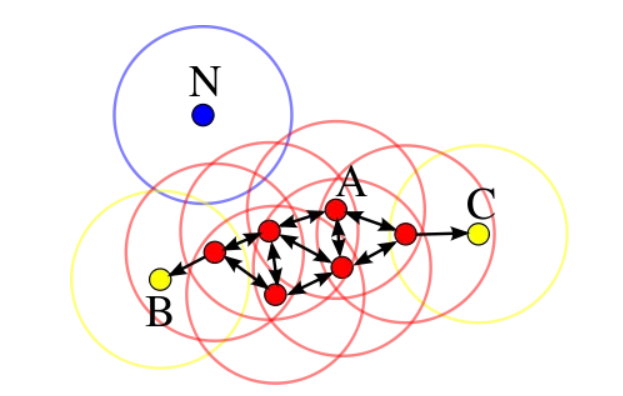

In [36]:
pivoted_df

date,2019-01-01,2019-02-01,2019-03-01,2019-04-01,2019-05-01,2019-06-01,2019-07-01,2019-08-01,2019-09-01,2019-10-01,...,2021-03-01,2021-04-01,2021-05-01,2021-06-01,2021-07-01,2021-08-01,2021-09-01,2021-10-01,2021-11-01,2021-12-01
feature_id,,,,,,,,,,,,,,,,,,,,,
0,0.094833,0.116266,0.041275,-0.003463,0.042498,-0.019456,-0.011366,-0.017914,-0.012596,-0.002706,...,0.009050,-0.005116,-0.000873,0.028900,-0.017801,-0.015649,-0.032630,-0.005064,0.006529,0.044334
1,0.061652,0.132942,0.008162,-0.005530,0.063989,-0.009637,-0.006807,-0.013802,-0.006500,-0.003272,...,0.002859,0.003246,-0.002630,0.013787,-0.029927,0.031022,-0.030269,0.000503,-0.000474,0.021063
2,0.094250,0.063221,-0.009423,-0.009157,0.107729,-0.015520,-0.013755,-0.015775,-0.003716,0.007274,...,0.005130,-0.006585,0.007772,0.034479,-0.027481,-0.008496,-0.027798,0.046410,0.025029,0.035262
3,0.109927,0.003998,-0.010714,-0.009956,0.096144,-0.013231,-0.009510,-0.017490,-0.003585,0.020747,...,0.006848,-0.006843,-0.000672,0.049379,-0.024425,-0.005992,-0.034516,0.016449,0.116825,0.033709
4,0.086098,0.007734,0.005219,-0.010751,0.096271,-0.015009,-0.013761,-0.015852,-0.003364,0.014884,...,0.034265,-0.007051,-0.002434,0.031080,-0.024039,-0.005714,-0.032275,0.063767,0.093399,0.066720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,0.151086,0.272270,0.431394,0.375502,0.379856,0.336836,0.302526,0.145142,0.242191,0.292851,...,0.330768,0.422152,0.024687,0.174523,0.246266,0.120027,0.090276,0.136289,0.154278,0.177634
102,0.159619,0.248704,0.326311,0.318180,0.330156,0.321391,0.303998,0.192359,0.275344,0.230093,...,0.316089,0.307273,0.015185,0.175153,0.271116,0.150383,0.150911,0.161670,0.153313,0.262657
103,0.146223,0.278045,0.417649,0.363990,0.370138,0.306579,0.275267,0.133523,0.232597,0.307866,...,0.334819,0.395802,0.028239,0.165529,0.233188,0.113923,0.155699,0.292372,0.293494,0.335051


<Axes: xlabel='date'>

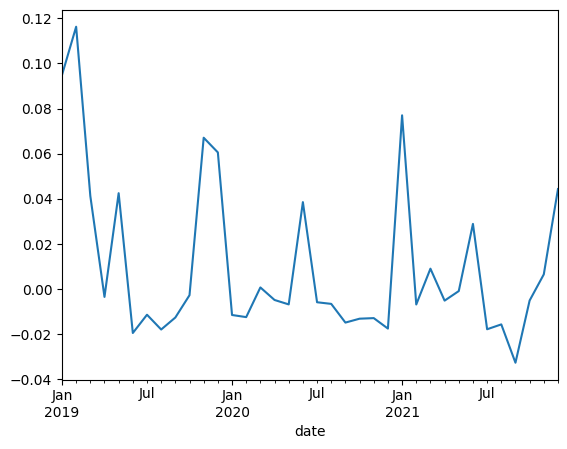

In [37]:
#Vamos visualizar um dado da serie temporal, como um exemplo
pivoted_df.iloc[0].plot()

<Axes: xlabel='date'>

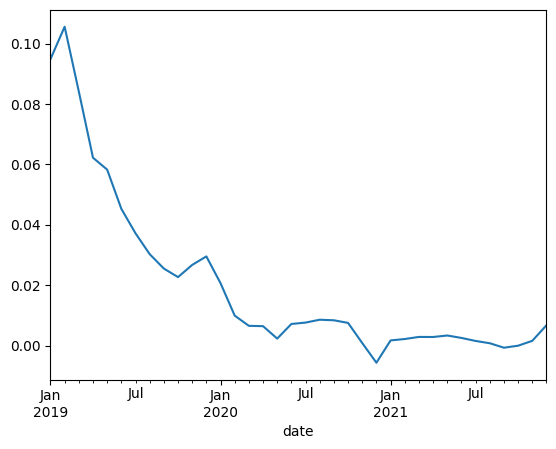

In [38]:
#Let's check what the result would be if we applied the moving average to smooth the series:
pivoted_df.iloc[0].rolling(window=12, min_periods=1).mean().plot()

In [39]:
#Precisamos aplicar para todos os dados
df_rolling_mean = pd.DataFrame()
for i,row in pivoted_df.iterrows():
  df_aux = pivoted_df.iloc[i].rolling(window=12, min_periods=1).mean()
  df_rolling_mean = pd.concat([df_rolling_mean,df_aux], axis=1)

In [40]:
df_rolling_mean = df_rolling_mean.T.reset_index(drop=True)

In [41]:
#Convertendo no formato adequado
time_series_dataset = to_time_series_dataset(df_rolling_mean)

In [42]:
!pip install sktime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.7/145.7 kB 13.9 MB/s eta 0:00:00


In [43]:
from sktime.clustering.dbscan import TimeSeriesDBSCAN
from sktime.dists_kernels import FlatDist, ScipyDist

eucl_dist = FlatDist(ScipyDist())
clst = TimeSeriesDBSCAN(distance=eucl_dist, eps=0.2)

In [44]:
clst.fit(time_series_dataset)

TimeSeriesDBSCAN(distance=FlatDist(transformer=ScipyDist()), eps=0.2)

In [45]:
#Pegando as labels originais do geodataframe
labels = clst.labels_
gdf_full['classe'] = labels

In [46]:
resultmap = folium.Map(location=[gdf_full.geometry.y.values[0],gdf_full.geometry.x.values[0]], zoom_start=10)
basemaps['Google Satellite Hybrid'].add_to(resultmap)

latitudes = list(gdf_full.geometry.y.values)
longitudes = list(gdf_full.geometry.x.values)
labels = list(gdf_full['classe'].values)
for lat, lng, label in zip(latitudes, longitudes, labels):
  if label == 0:
    folium.Marker(
      location = [lat, lng],
      popup = str(label),
      icon = folium.Icon(color='red')
     ).add_to(resultmap)
  elif label == 1:
    folium.Marker(
      location = [lat, lng],
      popup = str(label),
      icon = folium.Icon(color='blue')
     ).add_to(resultmap)
  elif label == 2:
    folium.Marker(
      location = [lat, lng],
      popup = str(label),
      icon = folium.Icon(color='black')
     ).add_to(resultmap)
  else:
    folium.Marker(
      location = [lat, lng],
      popup = str(label),
      icon = folium.Icon(color='green')
     ).add_to(resultmap)


vis_params = {'min': 0, 'max': 1}# Add the elevation model to the map object.
resultmap.add_child(folium.LayerControl())

# Display the map.
display(resultmap)